## This Jupyter noteebook uses the outputs from the notebook mesh_m2_Neches.ipynb.
## Here, we create the remaining workflow for Neches which includes the m3, exo file, and xml files for the steady, cyclic, and transient runs

In [1]:
## Importing all the package needed to run the watershed workflow
# conda package imports ()
# Use the branch "master" (git checkout master)

import ipympl
%matplotlib ipympl

%load_ext autoreload
%autoreload 2

import os,sys
import numpy as np
import pandas
import geopandas as gpd
from matplotlib import pyplot as plt
import logging
import pandas as pd
import copy
import scipy
import shapely
import pickle
import datetime
import h5py

import watershed_workflow 
import watershed_workflow.source_list
import watershed_workflow.ui
import watershed_workflow.utils
import watershed_workflow.plot
import watershed_workflow.mesh
import watershed_workflow.regions
import watershed_workflow.densification
import watershed_workflow.condition
watershed_workflow.ui.setup_logging(1,None)
import plot_wrm # $ATS_SRC_DIR/tools/utils
import watershed_workflow.land_cover_properties

# # # ats_input_spec library, to be moved to amanzi_xml (install package from repo "python setup.py install")
# # add "path"/ats_input_spec to PYTHONPATH
# Set the path to the amanzi source directory
# import ats_input_spec as ais
# ais.set_amanzi_source('/Users/gpq/ORNL/Projects/SETx_Urban/ATS_Implementation/ATS_Base/repos/amanzi')
import ats_input_spec
import ats_input_spec.public
import ats_input_spec.io



# # # amanzi_xml, included in AMANZI_SRC_DIR/tools/amanzi_xml  
# install it using: python setup.py install
import amanzi_xml.utils.io as aio
import amanzi_xml.utils.search as asearch
import amanzi_xml.utils.errors as aerrors


from shapely.geometry import Polygon, LineString
from shapely.ops import split

In [2]:
# Set working directory on the script folder    
os.chdir('/Users/gpq/ORNL/Projects/ATS_runs/setx_campaigns/setx-neches/scripts')

In [3]:
# Parameters cell -- this provides all parameters that can be changed via pipelining to generate a new watershed.
name = 'neches' # name the domain, used in filenames, etc

# simulation control
start_year = 1980  # year to start and end simulation simulation -- note these start and end Oct 1 of the year
end_year = 2020
min_porosity = 0.05 # minimum porosity considered too small
max_permeability = 1.e-10 # max value allowed for permeability
max_vg_alpha = 1.e-3 # max value of van Genuchten's alpha -- our correlation is not valid for some soils

# soil structure.
use_geologic_layer = True
SOILconfig = 2 # The subsurface layering is defined from SSURGO (top to bedrock), and SSD (set the depth to bedrock). Nodata values from SSURGO is filled with GLHYMPS. See workflow_viillage for more options

# logistics
generate_plots = True # plots take time to make and aren't always needed
generate_daymet = True # potentially don't do Met data forcing
generate_modis = True

include_heterogeneous = True
include_homogeneous = False # if true, also write files for homogeneous runs
include_homogeneous_wrm = False # if true, also write files for homogeneous WRMs
include_homogeneous_wrm_porosity = False # if true, also write files for homogeneous porosity and WRMs
include_homogeneous_wrm_permeability = False # if true, also write files for homogeneous perm and WRMs

log_to_file = False  # if true, write to file instead of in the notebook output
figsize = (6,6)
figsize_3d = (8,6)

In [4]:
# a dictionary of outputs -- will include all filenames generated
outputs = {}

In [5]:
# Note that, by default, we tend to work in the DayMet CRS because this allows us to avoid
# reprojecting meteorological forcing datasets.
crs = watershed_workflow.crs.daymet_crs()

## Sources and setup

Next we set up the source watershed and coordinate system and all data sources for our mesh.  We will use the CRS that is included in the shapefile.

In [6]:
logging.info("")
logging.info("="*30)


2024-04-25 14:05:25,462 - root - INFO: 
2024-04-25 14:05:25,462 - root - INFO: ==============================


A wide range of data sources are available; here we use the defaults except for using NHD Plus for watershed boundaries and hydrography (the default is NHD, which is lower resolution and therefore smaller download sizes).

In [7]:
# set up a dictionary of source objects
sources = watershed_workflow.source_list.get_default_sources()
sources['hydrography'] = watershed_workflow.source_list.hydrography_sources['NHD Plus']
sources['HUC'] = watershed_workflow.source_list.huc_sources['NHD Plus']
sources['DEM'] = watershed_workflow.source_list.dem_sources['NED 1/3 arc-second']
watershed_workflow.source_list.log_sources(sources)

2024-04-25 14:05:25,493 - root - INFO: Using sources:
2024-04-25 14:05:25,493 - root - INFO: --------------
2024-04-25 14:05:25,493 - root - INFO: HUC: National Hydrography Dataset Plus High Resolution (NHDPlus HR)
2024-04-25 14:05:25,494 - root - INFO: hydrography: National Hydrography Dataset Plus High Resolution (NHDPlus HR)
2024-04-25 14:05:25,494 - root - INFO: DEM: National Elevation Dataset (NED)
2024-04-25 14:05:25,494 - root - INFO: soil structure: National Resources Conservation Service Soil Survey (NRCS Soils)
2024-04-25 14:05:25,494 - root - INFO: geologic structure: GLHYMPS version 2.0
2024-04-25 14:05:25,495 - root - INFO: land cover: National Land Cover Database (NLCD) Layer: NLCD_2019_Land_Cover_L48
2024-04-25 14:05:25,495 - root - INFO: lai: MODIS
2024-04-25 14:05:25,495 - root - INFO: soil thickness: None
2024-04-25 14:05:25,495 - root - INFO: meteorology: DayMet 1km


### Loading data

In [8]:
## Load the mesh and rivers from the saved files
crs = watershed_workflow.crs.daymet_crs()
name = 'neches'
outputs = {}
outputs['m2_temp'] = f'../../../global_data/meshes/{name}_m2_temp.pkl'
outputs['rivers_temp'] = f'../../../global_data/meshes/{name}_rivers_temp.pkl'
outputs['watershed_temp'] = f'../../../global_data/meshes/{name}_watershed_temp.pkl'
outputs['subdomains_temp'] = f'../../../global_data/meshes/{name}_subdomains_temp.pkl'

m2 = pickle.load(open(outputs['m2_temp'], 'rb'))
rivers = pickle.load(open(outputs['rivers_temp'], 'rb'))
watershed = pickle.load(open(outputs['watershed_temp'], 'rb'))
subdomains = pickle.load(open(outputs['subdomains_temp'], 'rb'))



/Users/gpq/anaconda3/envs/watershed_workflow-master-2023-04-11/lib/python3.10/site-packages/pyproj/crs/crs.py:1282: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


kwargs =  {'linewidth': 0, 'cmap': <matplotlib.colors.ListedColormap object at 0x310de6bf0>, 'norm': <matplotlib.colors.BoundaryNorm object at 0x310de6c50>, 'edgecolor': 'w'}
setting face color =  [110.51894569 121.24179343  96.4969464  ...  -1.61300004  -1.61300004
  -1.61300004]


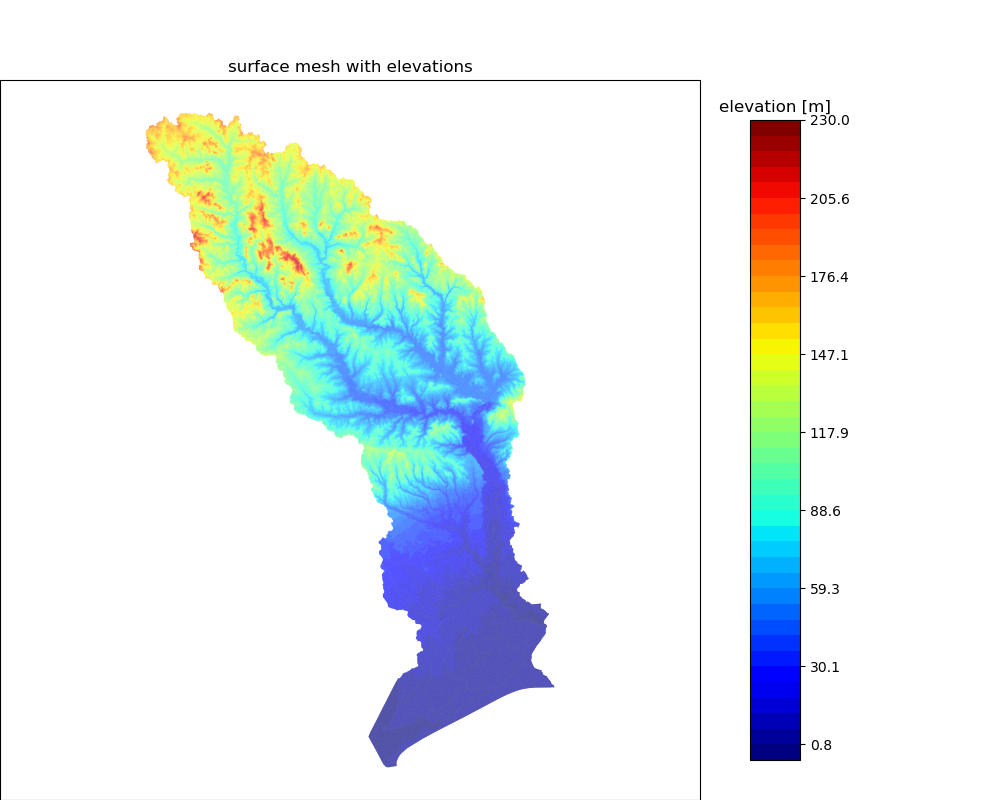

In [9]:
# plot the resulting surface mesh
start=min(m2.centroids[:,2])
step=(max(m2.centroids[:,2])-(min(m2.centroids[:,2])))/40
stop=max(m2.centroids[:,2])+step
legend_values=np.arange(start,stop,step)
indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(legend_values, cmap='jet')

# fig = plt.figure(figsize=figsize)
# ax = watershed_workflow.plot.get_ax(crs, fig, window=[0.05,0.1,0.9,0.8])
# cbax = fig.add_axes([0.05,0.05,0.9,0.05])

fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(10,8), window=[0.,0.,0.7,0.9])
cbax = fig.add_axes([0.75,0.05,0.05,0.8])

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, 
                        linewidth=0 ,color=m2.centroids[:,2], 
                        cmap=cmap, norm = norm, edgecolor='w', facecolor='color')

# cbar = fig.colorbar(mp, orientation="horizontal", cax=cbax)
# set color bar in vertical
cbar = fig.colorbar(mp, orientation="vertical", cax=cbax)


# watershed_workflow.plot.rivers(rivers, crs, ax=ax, colors='b', linewidth=0.5)
# watershed_workflow.plot.hucs(watershed, crs, ax=ax, linewidth=1, facecolor='color', alpha=0.4)
ax.set_title('surface mesh with elevations')
ax.set_aspect('equal', 'datalim')

cbar.ax.set_title('elevation [m]')

plt.show()
fig.savefig(f'../images/{name}_dem_mesh')

## Surface properties

Meshes interact with data to provide forcing, parameters, and more in the actual simulation.  Specifically, we need vegetation type on the surface to provide information about transpiration and subsurface structure to provide information about water retention curves, etc.

We'll start by downloading and collecting land cover from the NLCD dataset, and generate sets for each land cover type that cover the surface.  Likely these will be some combination of grass, deciduous forest, coniferous forest, and mixed forest.

In [10]:
# Set land cover classes using NLCD
sources['land cover'] = watershed_workflow.source_list.FileManagerRaster('../../../global_data/land_cover/NLCD_2016_Land_Cover_L48/NLCD_2016_Land_Cover_L48.img')
lc_profile, lc_raster = watershed_workflow.get_raster_on_shape(sources['land cover'], 
                                                     watershed.exterior(), crs)

lc = watershed_workflow.values_from_raster(m2.centroids, crs, lc_raster, lc_profile)

# Convert to int
lc = lc.astype(int)

# Remove zero
# lc = lc[lc != 0]
# what land cover types did we get?
logging.info('Found land cover dtypes: {}'.format(lc.dtype))
logging.info('Found land cover types: {}'.format(set(lc)))

2024-04-25 14:06:16,223 - root - INFO: 
2024-04-25 14:06:16,223 - root - INFO: Loading Raster
2024-04-25 14:06:16,223 - root - INFO: ------------------------------
2024-04-25 14:06:16,225 - root - INFO: Collecting raster
2024-04-25 14:06:16,291 - root - INFO: bounds in my_crs: (6953.764230649981, 698123.389428819, 209160.8689471243, 1052294.9730360438)
2024-04-25 14:06:16,360 - root - INFO: ... got raster of shape: (11806, 6741)
2024-04-25 14:06:16,414 - root - INFO: ... got raster bounds: (6945.0, 1052295.0, 209175.0, 698115.0)
2024-04-25 14:06:17,093 - root - INFO: Found land cover dtypes: int64
2024-04-25 14:06:17,116 - root - INFO: Found land cover types: {71, 41, 42, 43, 11, 81, 82, 52, 21, 22, 23, 24, 90, 31, 95}


kwargs =  {'linewidth': 0, 'cmap': <matplotlib.colors.ListedColormap object at 0x11845a1a0>, 'norm': <matplotlib.colors.BoundaryNorm object at 0x118459cf0>}
setting face color =  [42 42 43 ... 22 22 22]


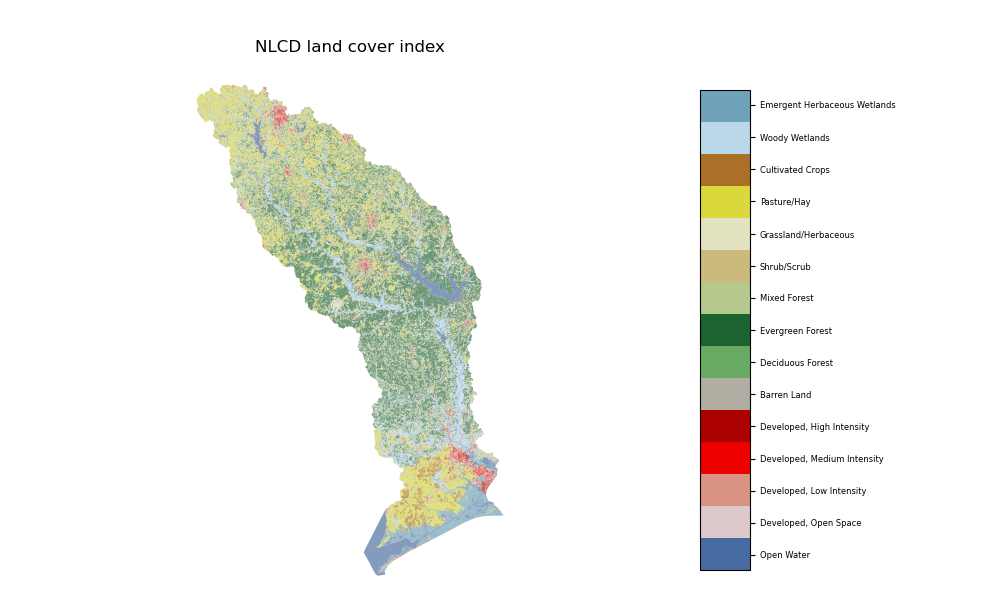

In [11]:
# nlcd_indices, nlcd_cmap, nlcd_norm, ticks, nlcd_labels = \
#         watershed_workflow.colors.generate_indexed_colormap(lc, cmap='tab20c')

nlcd_indices, nlcd_cmap, nlcd_norm, ticks, nlcd_labels = \
        watershed_workflow.colors.generate_nlcd_colormap(lc)

fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(10,6), window=[0.,0.,0.7,0.9])
cax = fig.add_axes([0.7,0.05,0.05,0.8])

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=lc, 
                        cmap=nlcd_cmap, norm=nlcd_norm
                       )

cbar = watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(lc)), 
                                                cmap=nlcd_cmap, labels=nlcd_labels, cax=cax)
cbar.ax.tick_params(labelsize=6)

# # Find the pos of the values of lc equal to zero
# pos = np.where(lc == 0)
# # plot the centroid of those elements
# ax.scatter(m2.centroids[pos,0], m2.centroids[pos,1], c='k', marker='o', s=1)

ax.set_title('NLCD land cover index')
ax.axis('off')
plt.show()
fig.savefig(f'../images/{name}_land_cover')

In [66]:
# Save data for plot 
outputs['lc'] = f'../../../global_data/meshes/{name}_lc.pkl'
pickle.dump(lc, open(outputs['lc'], 'wb'))

In [12]:
# Plot the count and frequency of lc
unique_values, counts = np.unique(lc, return_counts=True)

for value, count in zip(unique_values, counts):
    print(f"{value}: {100*count/np.sum(counts)}")

11: 7.20582394982734
21: 2.6335331834334554
22: 2.0707442779929166
23: 0.8884741954200321
24: 0.367023404754769
31: 0.13774450387618645
41: 1.0634230025939666
42: 20.469896256095527
43: 8.448920115569559
52: 3.247699460094694
71: 3.796020025363886
81: 15.99253551756058
82: 0.9857664012661274
90: 27.32508441095401
95: 5.367311295196954


In [13]:
# Set Manning values, by mapping land cover classes to manning roughness
# Map the lc and open channel elements to manning values

# As reference, Village runs used Min from HEC-RAS 2D (https://www.hec.usace.army.mil/confluence/rasdocs/r2dum/latest/developing-a-terrain-model-and-geospatial-layers/creating-land-cover-mannings-n-values-and-impervious-layers)
# and Paola's paper for open channels (https://onlinelibrary.wiley.com/doi/full/10.1111/1752-1688.12987)

# [NLCD_ID Manning_value]
NLCD_Manning_values = {
    'Open Water' : [11, 0.025], 
    'Perennial Ice/Snow' : [12, 0.1], 
    'Developed, Open Space' : [21, 0.03],
    'Developed, Low Intensity' : [22, 0.06],
    'Developed, Medium Intensity' : [23, 0.08],
    'Developed, High Intensity' : [24, 0.12],
    'Barren Land' : [31, 0.023],
    'Deciduous Forest' : [41, 0.10],
    'Evergreen Forest' : [42, 0.08],
    'Mixed Forest' : [43, 0.08],
    'Dwarf Scrub' : [51, 0.025],   
    'Shrub/Scrub' : [52, 0.07],
    'Grassland/Herbaceous' : [71, 0.025],
    'Sedge/Herbaceous' : [72, 0.025],
    'Lichens'  : [73, 0.1],
    'Moss'   : [74, 0.1],
    'Pasture/Hay' : [81, 0.025],
    'Cultivated Crops' : [82, 0.020],
    'Woody Wetlands' : [90, 0.045],
    'Emergent Herbaceous Wetlands' : [95, 0.05],

    'Open Channel 1' : [60, 0.2],
    'Open Channel 2' : [61, 0.1],
    'Open Channel 3' : [62, 0.065],
    'Open Channel 4' : [63, 0.045],
    'Open Channel 5' : [64, 0.03],
    'Open Channel 6' : [65, 0.01],
   
}




# Get the new NLCV_manning_labels as a dataframe with index as the NLCD name and column with the nlcd id
NLCD_Manning_labels = pd.DataFrame.from_dict(NLCD_Manning_values, orient='index')




# rename columns
NLCD_Manning_labels.columns = ['NLCD', 'Manning value']
NLCD_Manning_labels
# save table
NLCD_Manning_labels.to_csv(f'../data-processed/{name}_NLCD_Manning.csv')


In [14]:
# get a hard copy of lc to add the open channel labels

lc_channels = lc.copy()

for ls in m2.labeled_sets:
    name_label = ls.name
    # Look for the labels that are StreamOrder
    if 'StreamOrder' in name_label:
        # find what streamorder is this label by looking the number after StreamOrder. Name has this formar "reaches of StreamOrder 6 in neches corridor surface"
        stream_order = int(name_label.split(' ')[3])
        # get list of index of the elements that have this stream order
        index = ls.ent_ids
        # replace the land cover of those elements by the corresponding open channel class
        lc_channels[index] = 59 + stream_order

# Count of lc with the open channel classes
unique_values, counts = np.unique(lc_channels, return_counts=True)

for value, count in zip(unique_values, counts):
    print(f"{value}: {100*count/np.sum(counts)}")

11: 6.567297712673528
21: 2.6136023066668046
22: 2.0556853933247803
23: 0.8806494808375692
24: 0.3653994073885975
31: 0.13169142278409252
41: 1.0501357514161995
42: 20.416747251384457
43: 8.376135506340233
52: 3.240612926133218
60: 0.21569637745242057
61: 0.8714960411373296
62: 0.8561418842207987
63: 0.46623488021543064
64: 0.5461060234062312
65: 0.14335467659568815
71: 3.7815516851925395
81: 15.844899393363166
82: 0.9816325897885998
90: 25.363738500991378
95: 5.231190788686939


/Users/gpq/anaconda3/envs/watershed_workflow-master-2023-04-11/lib/python3.10/site-packages/pyproj/crs/crs.py:1282: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


kwargs =  {'linewidth': 0, 'cmap': <matplotlib.colors.ListedColormap object at 0x310ea5c30>, 'norm': <matplotlib.colors.BoundaryNorm object at 0x310ea5c90>}
setting face color =  [42 42 43 ... 60 60 60]


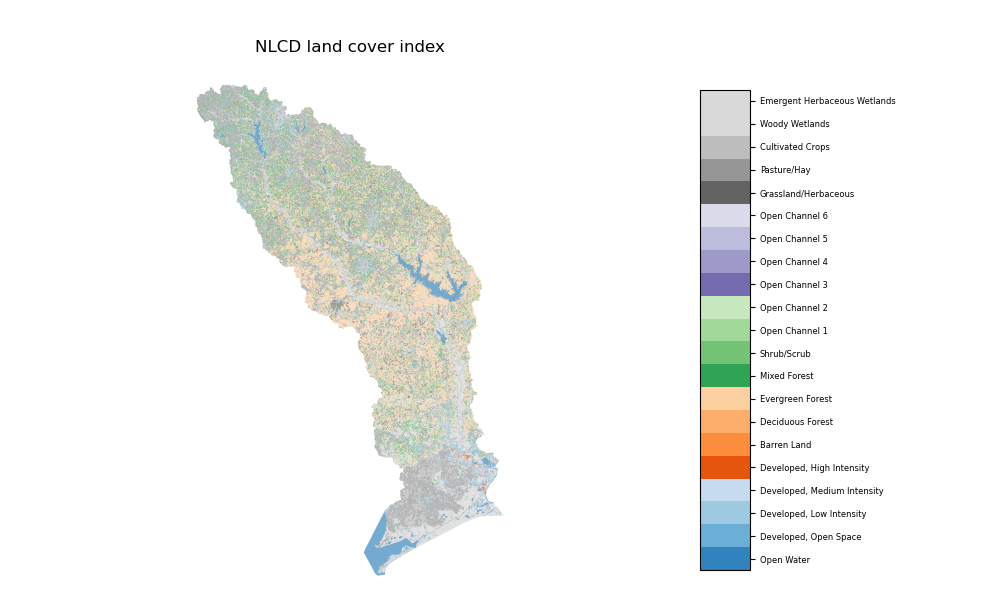

In [15]:
# do a new lc plot including the labels of the open channel classes

# Do a plot. Replace labels by NLCD labels
nlcd_indices, nlcd_cmap, nlcd_norm, ticks, nlcd_labels = \
        watershed_workflow.colors.generate_indexed_colormap(lc_channels, cmap='tab20c')

# replace nlcd labels
for key in nlcd_labels:
    nlcd_labels[np.where(np.array(nlcd_labels) == key)[0][0]] = NLCD_Manning_labels[NLCD_Manning_labels['NLCD']==int(key)].index[0]

fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(10,6), window=[0.,0.,0.7,0.9])
cax = fig.add_axes([0.7,0.05,0.05,0.8])

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=lc_channels, 
                        cmap=nlcd_cmap, norm=nlcd_norm
                       )

cbar = watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(lc_channels)), 
                                                cmap=nlcd_cmap, labels=nlcd_labels, cax=cax)
cbar.ax.tick_params(labelsize=6)

ax.set_title('NLCD land cover index')
ax.axis('off')
plt.show()
fig.savefig(f'../images/{name}_land_cover_and_open_channels')

In [16]:
# create the manning vector for plotting with the same length that lc_channels

manning = np.zeros(len(lc_channels))

# convert manning using the NLCD_Manning_values dictionary
for key in NLCD_Manning_values:
    # get the index of the elements that have this land cover type
    index = np.where(lc_channels == NLCD_Manning_values[key][0])
    # replace the manning value of those elements by the corresponding manning value
    manning[index] = NLCD_Manning_values[key][1]



kwargs =  {'linewidth': 0, 'cmap': <matplotlib.colors.ListedColormap object at 0x330038df0>, 'norm': <matplotlib.colors.BoundaryNorm object at 0x33003a6e0>}
setting face color =  [0.08 0.08 0.08 ... 0.2  0.2  0.2 ]


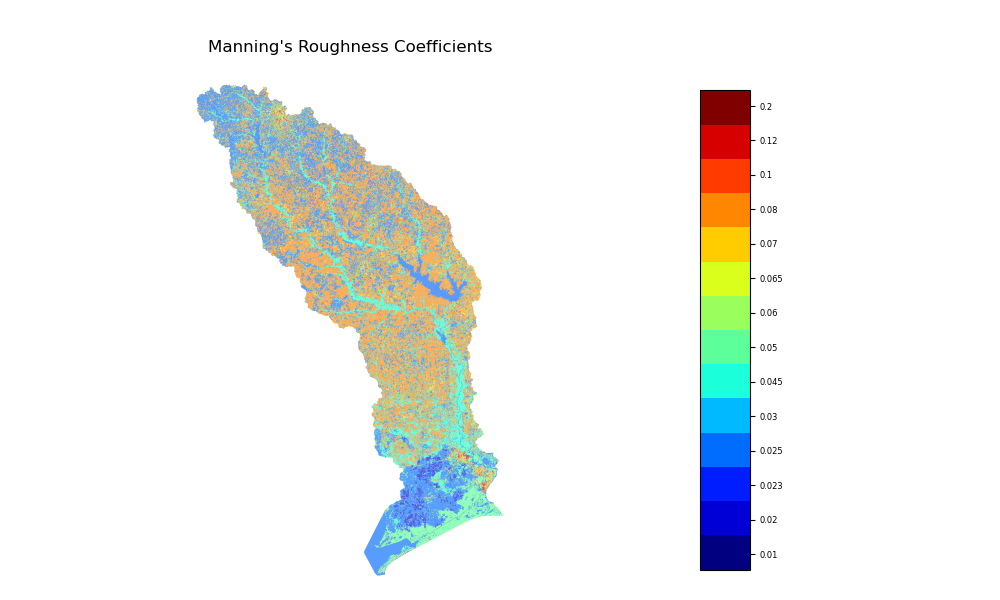

In [17]:
# Plot manning values

# Do a plot
indices, cmap, norm, ticks, labels = \
        watershed_workflow.colors.generate_indexed_colormap(manning, cmap='jet') # 'tab20c'
fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(10,6), window=[0.,0.,0.7,0.9])
cax = fig.add_axes([0.7,0.05,0.05,0.8])

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=manning, 
                        cmap=cmap, norm=norm
                       )

cbar = watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(manning)), 
                                                cmap=cmap, labels=labels, cax=cax)
cbar.ax.tick_params(labelsize=6)

ax.set_title('Manning\'s Roughness Coefficients')
ax.axis('off')
plt.show()
fig.savefig(f'../images/{name}_manning')

In [67]:
# Save data for plot 
outputs['manning'] = f'../../../global_data/meshes/{name}_manning.pkl'
pickle.dump(manning, open(outputs['manning'], 'wb'))

In [18]:
# Download Land Cover data from MODIS to do correlated with NLCD data.
# Any year could be use as a reference

# download MODIS data for LAI, block until it is finished!
# Put credentials in manager_modis_appeears.py
start = datetime.date(2017,1,1) # Dates to extract the land use data
end = datetime.date(2018,1,1)
# NOTE: if you get an error here about MODIS AppEEARs username and password, realize that 
# you must register for a login in the AppEEARs database.  See:

# watershed_workflow.config.rcParams['AppEEARS']['username'] = 'gmesa0325'
# watershed_workflow.config.rcParams['AppEEARS']['password'] = 'XXX'

print(sources['lai'].__doc__)

modis = sources['lai'].get_data(watershed.exterior(), crs, start, end)
if not isinstance(modis, watershed_workflow.datasets.State):
    modis = sources['lai'].wait(modis)


# resample the raster to the triangles
modis_lc = watershed_workflow.values_from_raster(m2.centroids, crs, modis['LULC'].data[0,:,:], modis['LULC'].profile)

# what land cover types did we get?
logging.info('Found land cover dtypes: {}'.format(modis_lc.dtype))
logging.info('Found land cover types: {}'.format(set(modis_lc)))

2024-04-25 14:08:52,550 - root - INFO: ... searching for: /Users/gpq/ORNL/Projects/ATS_runs/global_data/land_cover/MODIS/modis_LAI_01-01-2017_01-01-2018_32.5525x-95.9357_29.3405x-93.8277.nc
2024-04-25 14:08:52,551 - root - INFO: ... searching for: /Users/gpq/ORNL/Projects/ATS_runs/global_data/land_cover/MODIS/modis_LULC_01-01-2017_01-01-2018_32.5525x-95.9357_29.3405x-93.8277.nc
2024-04-25 14:08:52,551 - root - INFO: ... reading LAI from /Users/gpq/ORNL/Projects/ATS_runs/global_data/land_cover/MODIS/modis_LAI_01-01-2017_01-01-2018_32.5525x-95.9357_29.3405x-93.8277.nc


MODIS data through the AppEEARS data portal.

    Note this portal requires authentication -- please enter a
    username and password in your .watershed_workflowrc file.  For
    now, as this is not the highest security data portal or workflow
    package, we expect you to store this password in plaintext.  Maybe
    we can improve this?  If it bothers you, please ask how you can
    contribute (the developers of this package are not security
    experts!)

    To enter the username and password, register for a login in the
    AppEEARs data portal at:

    .. [AppEEARs](https://appeears.earthdatacloud.nasa.gov/)
    
    Currently the variables supported here include LAI and estimated
    ET.  

    All data returned includes a time variable, which is in units of
    [days past Jan 1, 2000, 0:00:00.

    Note this is implemented based on the API documentation here:

       https://appeears.earthdatacloud.nasa.gov/api/?python#introduction

    


2024-04-25 14:08:53,154 - root - INFO: ... reading LULC from /Users/gpq/ORNL/Projects/ATS_runs/global_data/land_cover/MODIS/modis_LULC_01-01-2017_01-01-2018_32.5525x-95.9357_29.3405x-93.8277.nc
2024-04-25 14:08:53,731 - root - INFO: Found land cover dtypes: int16
2024-04-25 14:08:53,752 - root - INFO: Found land cover types: {1, 2, 4, 5, 8, 9, 10, 11, 12, 13, 14, 16, 17}


kwargs =  {'linewidth': 0, 'cmap': <matplotlib.colors.ListedColormap object at 0x330087e80>, 'norm': <matplotlib.colors.BoundaryNorm object at 0x330086b60>}
setting face color =  [ 8  8  9 ... 13  9  9]


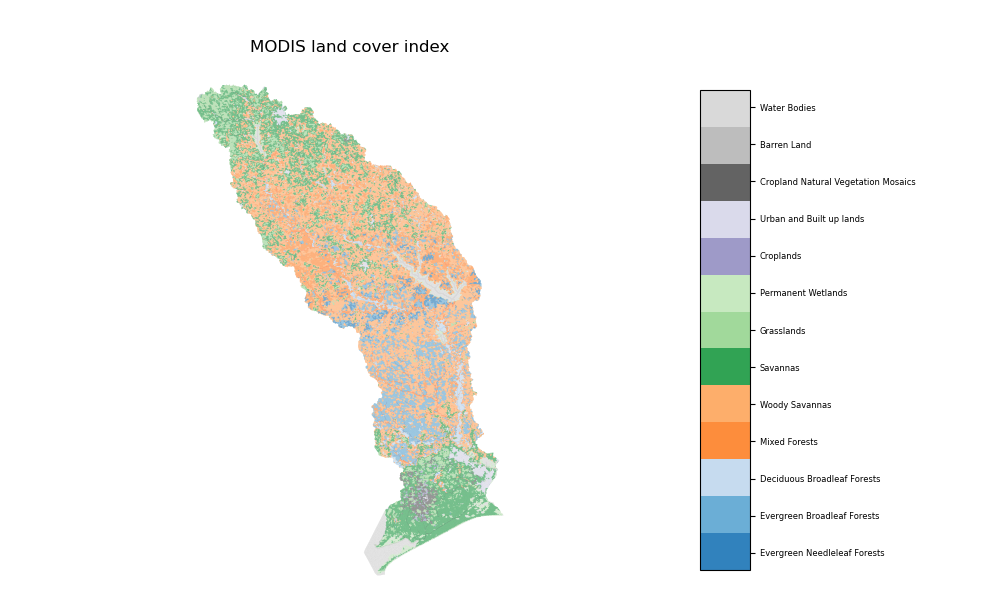

In [19]:
# Do a plot
modis_indices, modis_cmap, modis_norm, modis_ticks, modis_labels = \
        watershed_workflow.colors.generate_indexed_colormap(modis_lc, cmap='tab20c')

# Get the right labels, this is a bit of a hack
modis_indices_temp, modis_cmap_temp, modis_norm_temp, modis_ticks, modis_labels = \
                watershed_workflow.colors.generate_modis_colormap(modis_lc)

fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(10,6), window=[0.,0.,0.7,0.9])
cax = fig.add_axes([0.7,0.05,0.05,0.8])

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=modis_lc, 
                        cmap=modis_cmap, norm=modis_norm
                       )

cbar = watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(modis_lc)), 
                                                cmap=modis_cmap, labels=modis_labels, cax=cax)
cbar.ax.tick_params(labelsize=6)

# cb = fig.colorbar(mp)
# cb.set_ticks(modis_ticks[0:len(modis_labels)])
# cb.set_ticklabels(modis_labels)

ax.set_title("MODIS land cover index")
ax.axis('off')
plt.show()
fig.savefig(f'../images/{name}_MODIS_land_cover')

In [20]:

# print in two columns 
for i in range(0, len(nlcd_indices)):
    print(f'{nlcd_indices[i]}: {nlcd_labels[i]}')


11: Open Water
21: Developed, Open Space
22: Developed, Low Intensity
23: Developed, Medium Intensity
24: Developed, High Intensity
31: Barren Land
41: Deciduous Forest
42: Evergreen Forest
43: Mixed Forest
52: Shrub/Scrub
60: Open Channel 1
61: Open Channel 2
62: Open Channel 3
63: Open Channel 4
64: Open Channel 5
65: Open Channel 6
71: Grassland/Herbaceous
81: Pasture/Hay
82: Cultivated Crops
90: Woody Wetlands
95: Emergent Herbaceous Wetlands


In [21]:
# print in two columns 
for i in range(0, len(modis_indices)):
    print(f'{modis_indices[i]}: {modis_labels[i]}')

1: Evergreen Needleleaf Forests
2: Evergreen Broadleaf Forests
4: Deciduous Broadleaf Forests
5: Mixed Forests
8: Woody Savannas
9: Savannas
10: Grasslands
11: Permanent Wetlands
12: Croplands
13: Urban and Built up lands
14: Cropland Natural Vegetation Mosaics
16: Barren Land
17: Water Bodies


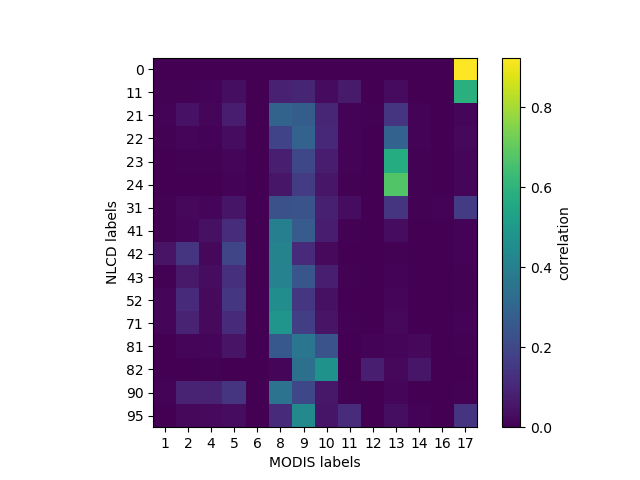

In [22]:

# determine a crosswalk between NLCD and MODIS -- for each NLCD index, 
# what MODIS index correlates best.  Note that while it is obvious here that
# all NLCD will map to MODIS 4, we do it anyway because this will not be true in general
crosswalk = watershed_workflow.land_cover_properties.compute_crosswalk_correlation(
    modis['LULC'].profile, modis['LULC'].data[0,:,:], lc_profile, lc_raster)

# This correlation is the proportion of common pixels between the two land covers over the total number of pixels of a NLCD land cover

# Note. This correlation is using the original raster resolution, not the mesh resolution. This means that some classes
# may not be well represented in the correlation plot, since that the mesh resolution could be much coarser than the raster resolution. 


## Subsurface properties

The default model uses GLHYMPS to identify geologic formations, and 

In [23]:
# Check if the m2.centroids are whitin the watershed bounds
# mesh_points2
# for i in range(len(m2.centroids)):
#     if m2.centroids[i][0] < watershed.exterior().bounds[0] or m2.centroids[i][0] > watershed.exterior().bounds[2]:
#         print('x out of bounds')
#     if m2.centroids[i][1] < watershed.exterior().bounds[1] or m2.centroids[i][1] > watershed.exterior().bounds[3]:
#         print('y out of bounds')

In [24]:
#Find the subdomain to split in order to download SSURGO data (large domain)
# # #  make a figre
# # fig, ax = plt.subplots()

# # # plot watershed.polygon(1)
# # watershed_workflow.plot.shply(watershed.polygon(0), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(1), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(2), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(3), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(4), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(5), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(6), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(7), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(8), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(9), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(10), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(11), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(12), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(13), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(14), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(15), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(16), crs, 'k', ax, facecolor='k', alpha=0.4)
# # # watershed_workflow.plot.shply(watershed.polygon(17), crs, 'k', ax, facecolor='k', alpha=0.4)

# watershed_workflow.plot.shply(watershed.exterior(), crs, 'k', ax, facecolor='k', alpha=0.4)

# Define large_poly
poly_to_split = watershed.polygon(2)
# Define the cutting line
centroid = poly_to_split.centroid
x, y = centroid.coords[0]
line = LineString([(x - 1000000, y), (x + 1000000, y)])
# Split the polygon using the line
subdomain_split = list(split(poly_to_split, line))

# create a deep copy of the subdomain
new_subdomains = copy.deepcopy(subdomains)

# remove the old suddomain in pos 2, and append the new subdomains
new_subdomains.pop(2)
new_subdomains.append(subdomain_split[0])
new_subdomains.append(subdomain_split[1])

In [25]:
soil_profile, soil_survey, soil_survey_props = \
        watershed_workflow.get_shapes(sources['soil structure'], list(new_subdomains[:]),
                                      crs, crs, properties=True, split_download=True)

2024-04-25 14:10:41,269 - root - INFO: 
2024-04-25 14:10:41,269 - root - INFO: Loading shapes
2024-04-25 14:10:41,269 - root - INFO: ------------------------------
2024-04-25 14:10:41,346 - root - INFO: Attempting to download source for target '/Users/gpq/ORNL/Projects/ATS_runs/global_data/soil_structure/SSURGO/SSURGO_-94.1377_29.9465_-93.8088_30.3848.shp'
2024-04-25 14:10:41,387 - root - INFO:   Found 1937 shapes.
2024-04-25 14:10:41,388 - root - INFO:   and crs: epsg:4326
2024-04-25 14:10:41,393 - root - INFO: Attempting to download source for target '/Users/gpq/ORNL/Projects/ATS_runs/global_data/soil_structure/SSURGO/SSURGO_-94.7271_30.0494_-93.9234_30.9837.shp'
2024-04-25 14:10:41,655 - root - INFO:   Found 13919 shapes.
2024-04-25 14:10:41,656 - root - INFO:   and crs: epsg:4326
2024-04-25 14:10:41,661 - root - INFO: Attempting to download source for target '/Users/gpq/ORNL/Projects/ATS_runs/global_data/soil_structure/SSURGO/SSURGO_-95.2129_30.8304_-94.3526_31.3772.shp'
2024-04-25

In [26]:
# soil_profile, soil_survey, soil_survey_props = \
#         watershed_workflow.get_shapes(sources['soil structure'], [watershed.exterior(),],
#                                       crs, crs, properties=True)


In [27]:
Load_SSURGO = True

if not Load_SSURGO:

    # download the NRCS soils data as shapes and project it onto the mesh
    # If an error appears then, the certifies need to set equal to False (manager_nrcs.py) requests.post(self.url_data, data=data, verify=False)
    # -- download the shapes


    # soil_profile, soil_survey, soil_survey_props = \
    #         watershed_workflow.get_shapes(sources['soil structure'], [watershed.exterior(),],
    #                                       crs, crs, properties=True)

    # -- determine the NRCS mukey for each soil unit; this uniquely identifies soil 
    #    properties
    soil_ids = np.array(soil_survey_props['mukey'][:], np.int32)
    soil_survey_props.set_index('mukey', inplace=True, drop=False)
    # soil_survey_props = soil_survey_props.loc[np.unique(soil_color), :]

    # Make the watershed bounds slighly larger to make sure that all the soil polygons are included. 
    watershed_bounds = [watershed.exterior().bounds[0]-20, watershed.exterior().bounds[1]-20, watershed.exterior().bounds[2]+20, watershed.exterior().bounds[3]+20]

    # -- color a raster by the polygons (this makes identifying a triangle's value much 
    #    more efficient)
    soil_color_profile, soil_color_raster = watershed_workflow.color_raster_from_shapes(soil_survey, crs, soil_ids,
                                                                                        watershed_bounds, 10, crs, -1)

    # soil_color_profile, soil_color_raster = watershed_workflow.color_raster_from_shapes(soil_survey, crs, soil_ids,
    #                                                                                     watershed.exterior().bounds, 10, crs, -1)

    # -- resample the raster to the triangles
    soil_color = watershed_workflow.values_from_raster(m2.centroids, crs, 
                                            soil_color_raster, soil_color_profile, algorithm='nearest') # 'nearest' 'piecewise bilinear'

    # save soil_survey_props and soil_colors to don't load it again
    outputs['soil_survey_props'] = f'../../../global_data/meshes/{name}_soil_survey_props_temp.pkl'
    outputs['soil_color'] = f'../../../global_data/meshes/{name}_soil_color_temp.pkl'

    # save data
    with open(outputs['soil_survey_props'], 'wb') as f:
        pickle.dump(soil_survey_props, f)
    with open(outputs['soil_color'], 'wb') as f:
        pickle.dump(soil_color, f)

else:
    # load soil_survey_props and soil_colors
    outputs['soil_survey_props'] = f'../../../global_data/meshes/{name}_soil_survey_props_temp.pkl'
    outputs['soil_color'] = f'../../../global_data/meshes/{name}_soil_color_temp.pkl'

    # load data
    with open(outputs['soil_survey_props'], 'rb') as f:
        soil_survey_props = pickle.load(f)
    with open(outputs['soil_color'], 'rb') as f:
        soil_color = pickle.load(f)

    

soil_survey_props

,mukey,residual saturation [-],Rosetta porosity [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],Rosetta permeability [m^2],thickness [cm],permeability [m^2],porosity [-],bulk density [g/cm^3],total sand pct [%],total silt pct [%],total clay pct [%],source
mukey,,,,,,,,,,,,,,
363783,363783,0.273007,0.490798,0.000089,1.277146,1.561165e-13,203.0,2.075912e-14,0.460443,1.343103,15.420197,28.778818,55.800985,NRCS
363789,363789,0.249554,0.521195,0.000075,1.319708,3.104307e-13,203.0,2.000000e-15,0.528957,1.200000,14.568966,35.431034,50.000000,NRCS
363796,363796,0.177187,0.374718,0.000167,1.483510,4.634823e-13,178.0,2.412447e-12,0.400487,1.515449,67.991386,20.727715,11.280899,NRCS
363801,363801,0.227770,0.402504,0.000079,1.383127,1.466453e-13,203.0,2.317765e-14,0.427389,1.435222,40.199507,36.320690,23.479803,NRCS
363802,363802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NRCS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3009460,3009460,0.175263,0.407994,0.000161,1.503612,7.454593e-13,203.0,1.070324e-12,0.631527,1.392020,70.133498,17.248276,12.618227,NRCS
3100753,3100753,0.252387,0.432744,0.000079,1.336146,1.307706e-13,203.0,3.725695e-13,0.437327,1.403010,32.674433,32.729507,34.596059,NRCS
3220253,3220253,0.133235,0.368627,0.000357,3.871812,1.451681e-11,203.0,1.174083e-11,0.420113,1.536059,98.265025,0.000000,1.734975,NRCS


Select only the soils within the watershed

/Users/gpq/anaconda3/envs/watershed_workflow-master-2023-04-11/lib/python3.10/site-packages/pyproj/crs/crs.py:1282: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


kwargs =  {'linewidth': 0.5, 'cmap': <matplotlib.colors.ListedColormap object at 0x3442b84c0>}
setting face color =  [0.39325688 0.35684729 0.41407895 ...        nan        nan        nan]
Median porosity [-] =  0.42221674876847287


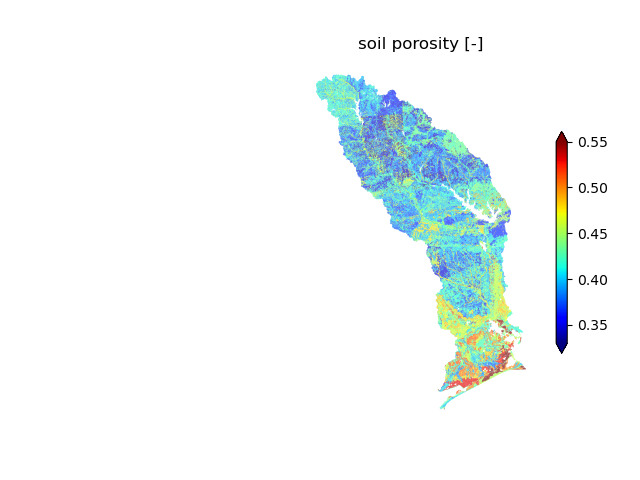

In [28]:
# plot of porosity from SSURGO
iprop = np.empty(soil_color.shape, 'd')
for mukey in soil_survey_props['mukey']:
    # iprop[soil_color == mukey] = soil_survey_props.loc[ mukey,'porosity [-]']
    iprop[soil_color == mukey] = soil_survey_props[soil_survey_props['mukey']==mukey]['porosity [-]'].values[0]

pmin_plot = 0.33
pmax_plot = 0.55

fig, ax = watershed_workflow.plot.get_ax(crs)
indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(iprop, cmap='jet')
mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                        linewidth=0.5, color=iprop, cmap=cmap, facecolor='color', vmin=pmin_plot, vmax=pmax_plot)

# mp = watershed_workflow.plot.triangulation(mesh_points3, mesh_tris, crs, ax=ax, 
#                                  color=iprop, edgecolor='gray', cmap='jet')
ax.set_title('soil porosity [-]')
cb = fig.colorbar(mp, fraction=0.04, pad=0.04, extend="both", shrink=0.6)
ax.axis('off')



print('Median porosity [-] = ', np.nanmedian(iprop))
plt.show()
fig.savefig(f'../images/{name}_soil_porosity')

/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_29990/566164952.py:11: RuntimeWarning: divide by zero encountered in log10
  indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(np.log10(iprop), cmap='jet')
/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_29990/566164952.py:13: RuntimeWarning: divide by zero encountered in log10
  linewidth=0.5, color=np.log10(iprop), cmap=cmap, facecolor='color')


kwargs =  {'linewidth': 0.5, 'cmap': <matplotlib.colors.ListedColormap object at 0x3324f4ac0>}
setting face color =  [-13.07870919 -11.43903567 -12.04575749 ...          nan          nan
          nan]
Min k [m^2] =  0.0


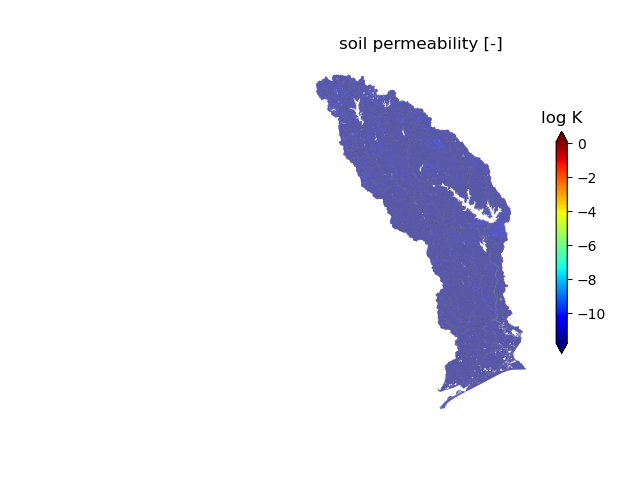

In [29]:
# plot of permeability
iprop = np.empty(soil_color.shape, 'd')
for mukey in soil_survey_props['mukey']:
    # iprop[soil_color == mukey] = soil_survey_props.loc[ mukey,'porosity [-]']
    iprop[soil_color == mukey] = soil_survey_props[soil_survey_props['mukey']==mukey]['permeability [m^2]'].values[0]
# for mukey in soil_survey_props.index:
#     iprop[soil_color == mukey] = soil_survey_props.loc[ mukey,'permeability [m^2]']

fig, ax = watershed_workflow.plot.get_ax(crs)

indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(np.log10(iprop), cmap='jet')
mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                        linewidth=0.5, color=np.log10(iprop), cmap=cmap, facecolor='color')

# mp = watershed_workflow.plot.triangulation(mesh_points3, mesh_tris, crs, ax=ax, 
#                                  color=np.log10(iprop), edgecolor='gray', cmap='jet')
ax.set_title('soil permeability [-]')
cb = fig.colorbar(mp, fraction=0.04, pad=0.04, extend="both", shrink=0.6)
cb.ax.set_title('log K')
ax.axis('off')

print('Min k [m^2] = ', np.nanmin(iprop))
plt.show()
fig.savefig(f'../images/{name}_soil_permeability')

In [30]:
# Note the missing data (white).  This is because some SSURGO map units have no formation with complete 
# information.  So we merge the above available data, filling where possible and dropping regions that
# do not have a complete set of properties.
soil_survey_props_clean = soil_survey_props.copy()

# later scripts expect 'native_index' as a standard name of holding onto the original IDs
soil_survey_props_clean.rename_axis('native_index', inplace=True)
soil_survey_props_clean.rename(columns={'mukey':'native_index'}, inplace=True)

# need thickness in m
soil_survey_props_clean['thickness [cm]'] = soil_survey_props_clean['thickness [cm]']/100.
soil_survey_props_clean.rename(columns={'thickness [cm]':'thickness [m]'}, inplace=True)

# clean data
def replace_column_nans(df, col_nan, col_replacement):
    """In a df, replace col_nan entries by col_replacement if is nan.  In Place!"""
    row_indexer = df[col_nan].isna()
    df.loc[row_indexer, col_nan] = df.loc[row_indexer, col_replacement]
    return

# where poro or perm is nan, put Rosetta poro
replace_column_nans(soil_survey_props_clean, 'porosity [-]', 'Rosetta porosity [-]')
replace_column_nans(soil_survey_props_clean, 'permeability [m^2]', 'Rosetta permeability [m^2]')

# drop unnecessary columns
for col in ['Rosetta porosity [-]', 'Rosetta permeability [m^2]', 'bulk density [g/cm^3]', 'total sand pct [%]',
            'total silt pct [%]', 'total clay pct [%]']:
    soil_survey_props_clean.pop(col)
    
# drop nans
soil_survey_props_clean.dropna(inplace=True)
soil_survey_props_clean.reset_index(drop=True, inplace=True)
soil_survey_props_clean.rename_axis('native_index', inplace=True)

assert soil_survey_props_clean['porosity [-]'][:].min() >= min_porosity
assert soil_survey_props_clean['permeability [m^2]'][:].max() <= max_permeability


# print the min and max of the porosity and permeability
print('min porosity', soil_survey_props_clean['porosity [-]'][:].min())
print('max porosity', soil_survey_props_clean['porosity [-]'][:].max())

soil_survey_props_clean

min porosity 0.30787401574803147
max porosity 0.7406781094983319


,native_index,residual saturation [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],thickness [m],permeability [m^2],porosity [-],source
native_index,,,,,,,,
0,363783,0.273007,0.000089,1.277146,2.03,2.075912e-14,0.460443,NRCS
1,363789,0.249554,0.000075,1.319708,2.03,2.000000e-15,0.528957,NRCS
2,363796,0.177187,0.000167,1.483510,1.78,2.412447e-12,0.400487,NRCS
3,363801,0.227770,0.000079,1.383127,2.03,2.317765e-14,0.427389,NRCS
4,366063,0.235830,0.000070,1.351201,1.52,2.913497e-14,0.515556,NRCS
...,...,...,...,...,...,...,...,...
1278,3009460,0.175263,0.000161,1.503612,2.03,1.070324e-12,0.631527,NRCS
1279,3100753,0.252387,0.000079,1.336146,2.03,3.725695e-13,0.437327,NRCS
1280,3220253,0.133235,0.000357,3.871812,2.03,1.174083e-11,0.420113,NRCS


In [68]:
# Save data for plots

outputs['soil_colors'] = f'../../../global_data/meshes/{name}_soil_color.pkl'
pickle.dump(soil_color, open(outputs['soil_colors'], 'wb'))

outputs['soil_survey_props'] = f'../../../global_data/meshes/{name}_soil_survey_props.pkl'
pickle.dump(soil_survey_props_clean, open(outputs['soil_survey_props'], 'wb'))

/Users/gpq/anaconda3/envs/watershed_workflow-master-2023-04-11/lib/python3.10/site-packages/pyproj/crs/crs.py:1282: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


kwargs =  {'linewidth': 0, 'cmap': <matplotlib.colors.ListedColormap object at 0x3325d2740>, 'norm': <matplotlib.colors.BoundaryNorm object at 0x3325d1b70>}
setting face color =  [577090. 575627. 575340. ... 374939. 374939. 374939.]


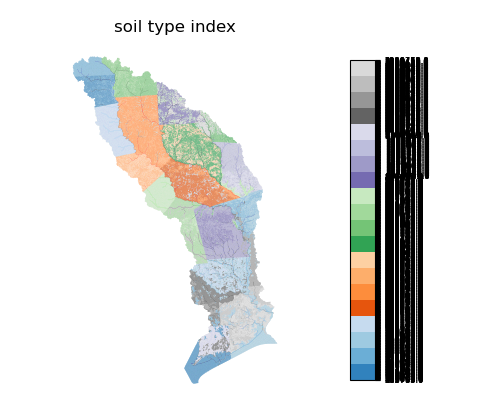

In [31]:
# plot the soil mukey
indices, cmap, norm, ticks, labels = \
        watershed_workflow.colors.generate_indexed_colormap(soil_color, cmap='tab20c')
fig, ax = watershed_workflow.plot.get_ax(crs, figsize=(5,4), window=[0.,0.,0.7,0.9])
cax = fig.add_axes([0.7,0.05,0.05,0.8])

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=soil_color, 
                        cmap=cmap, norm=norm
                       )

cbar = watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(soil_color)), 
                                                cmap=cmap, labels=labels, cax=cax)
cbar.ax.tick_params(labelsize=6)

ax.set_title('soil type index')
ax.axis('off')
plt.show()

In [32]:
print('min permeability', np.log10(soil_survey_props_clean['permeability [m^2]'][:].min()))
print('max permeability', np.log10(soil_survey_props_clean['permeability [m^2]'][:].max()))

min permeability -15.19669201672849
max permeability -10.698970004336019


In [33]:
# create a new soil_color, keeping on those that are kept here and re-indexing to ATS indices
soil_color_new = -np.ones_like(soil_color)
# for new_id, mukey in enumerate(soil_survey_props_clean['mukey']):
#     soil_color_new[np.where(soil_color == mukey)] = 2000+new_id

for new_id, mukey in enumerate(soil_survey_props_clean['native_index']):
    soil_color_new[np.where(soil_color == mukey)] = 2000+new_id

kwargs =  {'linewidth': 0, 'cmap': <matplotlib.colors.ListedColormap object at 0x332a3bc70>, 'norm': <matplotlib.colors.BoundaryNorm object at 0x332a387f0>}
setting face color =  [ 2.709e+03  2.501e+03  2.378e+03 ... -1.000e+00 -1.000e+00 -1.000e+00]


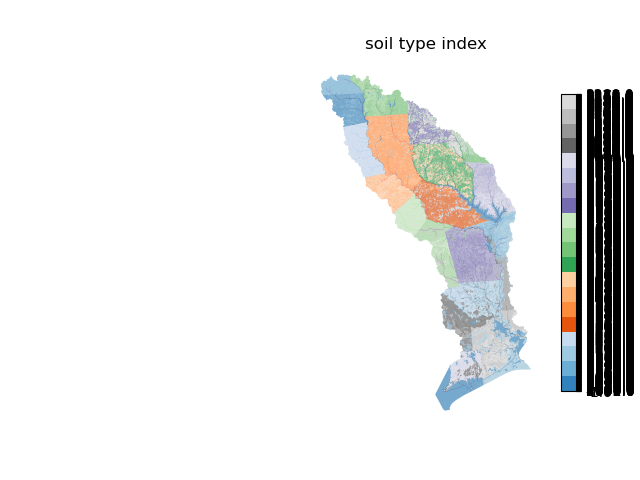

In [34]:
# image the new soil_color
indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(soil_color_new, cmap='tab20c')
fig, ax = watershed_workflow.plot.get_ax(crs)

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=soil_color_new, 
                        cmap=cmap, norm=norm)

watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(soil_color_new)), cmap=cmap, labels=labels) 

ax.set_title('soil type index')
ax.axis('off')
plt.show()
fig.savefig(f'../images/{name}_soil_indices')

### GLYHMPS geologic layer

GLYHMPS is complete in that it does not appear to have missing data, but does not have texture properties needed for Water Retention Models.  Instead we rely on scaling laws to fill the data.

In [35]:
Load_GLYHMPS = True

if not Load_GLYHMPS:

    # extract the GLYHMPS geologic structure data as shapes and project it onto the mesh
    target_bounds = watershed.exterior().bounds
    logging.info('target bounds: {}'.format(target_bounds))

    _, geo_survey, geo_survey_props = watershed_workflow.get_shapes(sources['geologic structure'], 
                                                        target_bounds, crs, crs, properties=True,
                                                        min_porosity=min_porosity, 
                                                        max_permeability=max_permeability,
                                                        max_vg_alpha=max_vg_alpha)

    # # -- log the bounds targeted and found
    # logging.info('shape union bounds: {}'.format(
    #     shapely.ops.cascaded_union(geo_survey).bounds))

    valid_geometries = [geom for geom in geo_survey if geom and not geom.is_empty and geom.is_valid]

    if valid_geometries:
        union_result = shapely.ops.cascaded_union(valid_geometries)
        logging.info('shape union bounds: {}'.format(union_result.bounds))
    else:
        logging.warning('No valid geometries found in geo_survey')


    # -- determine the ID for each soil unit; this uniquely identifies formation
    #    properties
    geo_ids = np.array([shp.properties['id'] for shp in geo_survey], np.int32)

    # -- color a raster by the polygons (this makes identifying a triangle's value much 
    #    more efficient)

    # Make the watershed bounds slighly larger to make sure that all the soil polygons are included. 
    watershed_bounds = [watershed.exterior().bounds[0]-20, watershed.exterior().bounds[1]-20, watershed.exterior().bounds[2]+20, watershed.exterior().bounds[3]+20]

    geo_color_profile, geo_color_raster = \
                watershed_workflow.color_raster_from_shapes(geo_survey, crs, geo_ids,
                                                            watershed_bounds, 10, crs, -1)

    # -- resample the raster to the triangles
    geo_color = watershed_workflow.values_from_raster(m2.centroids, crs, 
                                            geo_color_raster, geo_color_profile, algorithm='nearest') # 'nearest' 'piecewise bilinear'
    

    # save soil_survey_props and soil_colors to don't load it again
    outputs['geo_survey_props'] = f'../../../global_data/meshes/{name}_geo_survey_props_temp.pkl'
    outputs['geo_color'] = f'../../../global_data/meshes/{name}_geo_color_temp.pkl'

    # save data
    with open(outputs['geo_survey_props'], 'wb') as f:
        pickle.dump(geo_survey_props, f)
    with open(outputs['geo_color'], 'wb') as f:
        pickle.dump(geo_color, f)

else:
    # load soil_survey_props and soil_colors
    outputs['geo_survey_props'] = f'../../../global_data/meshes/{name}_geo_survey_props_temp.pkl'
    outputs['geo_color'] = f'../../../global_data/meshes/{name}_geo_color_temp.pkl'

    # load data
    with open(outputs['geo_survey_props'], 'rb') as f:
        geo_survey_props = pickle.load(f)
    with open(outputs['geo_color'], 'rb') as f:
        geo_color = pickle.load(f)

In [36]:
np.min(geo_color)

-1.0

In [37]:
# select the properties that appear in the mesh
geo_survey_props.set_index('id', inplace=True, drop=False)
# geo_survey_props = geo_survey_props.loc[np.unique(geo_color), :]
geo_survey_props = geo_survey_props.loc[np.unique(geo_color[geo_color != -1]), :]

/Users/gpq/anaconda3/envs/watershed_workflow-master-2023-04-11/lib/python3.10/site-packages/pyproj/crs/crs.py:1282: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


kwargs =  {'linewidth': 0, 'cmap': <matplotlib.colors.ListedColormap object at 0x3320d3cd0>, 'norm': <matplotlib.colors.BoundaryNorm object at 0x333024f70>}
setting face color =  [ 601093. 1792075.  675627. ... 1791057. 1791057. 1791057.]


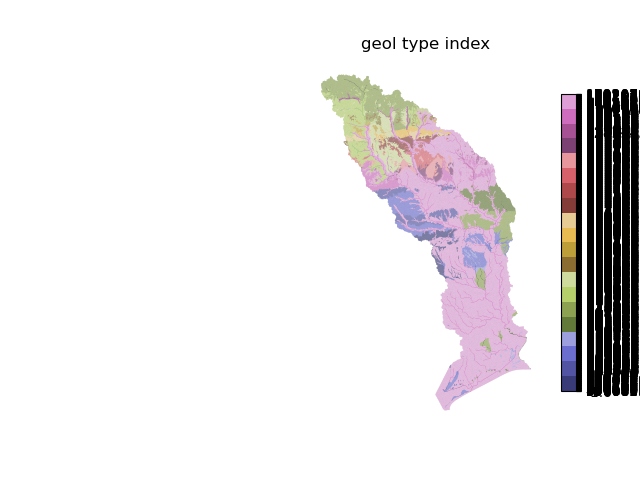

In [38]:
# plot the geologic formation id
indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(geo_color, cmap='tab20b')

fig, ax = watershed_workflow.plot.get_ax(crs)

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=geo_color, 
                        cmap=cmap, norm=norm)

watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(geo_color)), cmap=cmap, labels=labels) 

ax.set_title('geol type index')
ax.axis('off')
plt.show()
fig.savefig(f'../images/{name}_geo_index')

In [39]:
np.min(geo_color)

-1.0

/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_29990/3173823990.py:13: RuntimeWarning: divide by zero encountered in log10
  indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(np.log10(iprop), cmap='jet')
/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_29990/3173823990.py:15: RuntimeWarning: divide by zero encountered in log10
  linewidth=0.5, color=np.log10(iprop), cmap=cmap, facecolor='color', vmin=pmin_plot, vmax=pmax_plot)


kwargs =  {'linewidth': 0.5, 'cmap': <matplotlib.colors.ListedColormap object at 0x330f083a0>}
setting face color =  [-13.   -12.5  -15.2  ... -14.95 -14.95 -14.95]


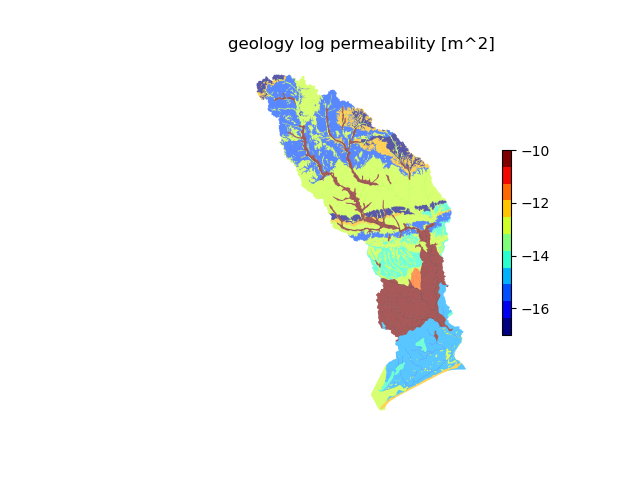

In [40]:
# plot permeability of the underlying geologic layer
iprop = np.empty(geo_color.shape, 'd')

for i in geo_survey_props.index:
    # iprop[geo_color == i] = geo_survey_props.loc[i, 'permeability [m^2]']
    iprop[geo_color == i] = geo_survey_props[geo_survey_props['id']==i]['permeability [m^2]'].values[0]
    
fig, ax = watershed_workflow.plot.get_ax(crs)

pmin_plot = -17
pmax_plot = -10

indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(np.log10(iprop), cmap='jet')
mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                        linewidth=0.5, color=np.log10(iprop), cmap=cmap, facecolor='color', vmin=pmin_plot, vmax=pmax_plot)

# mp = watershed_workflow.plot.triangulation(mesh_points3, mesh_tris, crs, ax=ax, 
#                                  color=np.log10(iprop), edgecolor='gray', cmap='jet')
cbar = fig.colorbar(mp, shrink=0.5)
ax.set_title('geology log permeability [m^2]')
ax.axis('off')
plt.show()
fig.savefig(f'../images/{name}_geo_permeability')

kwargs =  {'linewidth': 0.5, 'cmap': <matplotlib.colors.ListedColormap object at 0x330fb7250>}
setting face color =  [0.22 0.27 0.19 ... 0.05 0.05 0.05]


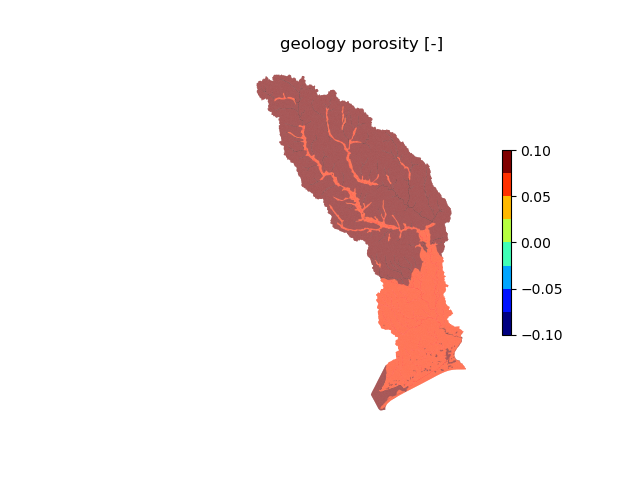

In [41]:
# plot porosity of the geologic layer
iprop = np.empty(geo_color.shape, 'd')
for i in geo_survey_props.index:
    iprop[geo_color == i] = geo_survey_props.loc[i, 'porosity [-]']

fig, ax = watershed_workflow.plot.get_ax(crs)

indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(iprop, cmap='jet')
mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                        linewidth=0.5, color=iprop, cmap=cmap, facecolor='color')

# mp = watershed_workflow.plot.triangulation(mesh_points3, mesh_tris, crs, ax=ax, 
#                                  color=iprop, edgecolor='gray', cmap='jet')
cbar = fig.colorbar(mp, shrink=0.5)
ax.set_title('geology porosity [-]')
ax.axis('off')
plt.show()
fig.savefig(f'../images/{name}_geo_porosity')

In [71]:
# Save data for plots

outputs['geo_colors'] = f'../../../global_data/meshes/{name}_geo_color.pkl'
pickle.dump(geo_color, open(outputs['geo_colors'], 'wb'))

outputs['geo_survey_props'] = f'../../../global_data/meshes/{name}_geo_survey_props.pkl'
pickle.dump(geo_survey_props, open(outputs['geo_survey_props'], 'wb'))

In [42]:
# note there are clearly some common regions -- no need to duplicate those with identical values.
geo_survey_props_clean = geo_survey_props.copy()
geo_survey_props_clean.pop('logk_stdev [-]')
geo_survey_props_clean.rename(columns={'id':'native_index'}, inplace=True)


def reindex_remove_duplicates(df, index=None):
    """Removes duplicates, creating a new index and saving the old index as tuples of duplicate values. In place!"""
    if index is not None:
        if index in df:
            df.set_index(index, drop=True, inplace=True)
    
    index_name = df.index.name

    # identify duplicate rows
    duplicates = list(df.groupby(list(df)).apply(lambda x: tuple(x.index)))

    # order is preserved
    df.drop_duplicates(inplace=True)
    df.reset_index(inplace=True)
    df[index_name] = duplicates
    return

reindex_remove_duplicates(geo_survey_props_clean, 'native_index')
assert geo_survey_props_clean['porosity [-]'][:].min() >= min_porosity
assert geo_survey_props_clean['permeability [m^2]'][:].max() <= max_permeability
assert geo_survey_props_clean['van Genuchten alpha [Pa^-1]'][:].max() <= max_vg_alpha

geo_survey_props_clean

,native_index,source,permeability [m^2],porosity [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],residual saturation [-]
0,"(600714, 600725, 600729, 600735, 600766, 60077...",GLHYMPS,1.000000e-13,0.22,0.000294,2.0,0.01
1,"(596091, 596103, 596127, 596189, 596197, 63062...",GLHYMPS,6.309573e-16,0.19,0.000025,2.0,0.01
2,"(602066, 1791057)",GLHYMPS,1.000000e-14,0.15,0.000113,2.0,0.01
3,"(602079, 644147, 644151, 1791058)",GLHYMPS,3.162278e-17,0.12,0.000007,2.0,0.01
4,"(596176, 596179, 596185, 596190, 596195, 59620...",GLHYMPS,3.162278e-13,0.27,0.000472,2.0,0.01
5,"(596075, 596080, 596082, 596087, 596088, 59609...",GLHYMPS,3.019952e-11,0.05,0.001000,2.0,0.01
6,"(641942, 641964, 641972, 641973, 641974)",GLHYMPS,1.122018e-15,0.05,0.000065,2.0,0.01
7,"(600806, 600812, 600827, 600828, 600844, 60085...",GLHYMPS,7.413102e-15,0.05,0.000168,2.0,0.01
8,"(1791056,)",GLHYMPS,4.466836e-12,0.05,0.001000,2.0,0.01
9,"(602129, 644230)",GLHYMPS,3.162278e-13,0.09,0.000817,2.0,0.01


/Users/gpq/anaconda3/envs/watershed_workflow-master-2023-04-11/lib/python3.10/site-packages/pyproj/crs/crs.py:1282: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


kwargs =  {'linewidth': 0, 'cmap': <matplotlib.colors.ListedColormap object at 0x3310ab7c0>, 'norm': <matplotlib.colors.BoundaryNorm object at 0x3310ab850>}
setting face color =  [105. 107. 101. ... 102. 102. 102.]


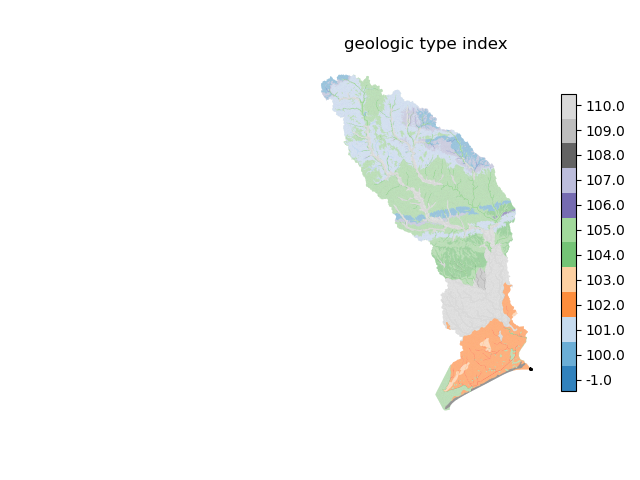

In [43]:
# create a new geologic layer color, keeping on those that are kept here and re-indexing to ATS indices
geo_color_new = -np.ones_like(geo_color)
for new_id, old_id_dups in enumerate(geo_survey_props_clean['native_index']):
    for old_id in old_id_dups:
        geo_color_new[np.where(geo_color == old_id)] = 100+new_id
    
# image the new geo_color
indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(geo_color_new, cmap='tab20c')
fig, ax = watershed_workflow.plot.get_ax(crs)

mp = watershed_workflow.plot.mesh(m2, crs, ax=ax, facecolor='color',
                        linewidth=0, color=geo_color_new, 
                        cmap=cmap, norm=norm)

watershed_workflow.colors.colorbar_index(ncolors=len(np.unique(geo_color_new)), cmap=cmap, labels=labels) 

# show with an x the location where geo_color is -1
pos = np.where(geo_color == -1)
ax.scatter(m2.centroids[pos,0], m2.centroids[pos,1], c='k', marker='x', s=1)

ax.set_title('geologic type index')
ax.axis('off')
plt.show()
fig.savefig(f'../images/{name}_geo_indices')

## Depth-to-bedrock

Depth to bedrock is taken from the [SoilGrids](http://globalchange.bnu.edu.cn/research/dtb.jsp) product.  Here we download a US-based, clipped version of this global product, as file sizes are quite large (all products potentially used total over 100GB).

In [44]:
# set the location of the depth to bedrock dataset. This can be SoilGrids2017 or SoilSedimentaryDeposit (https://daac.ornl.gov/SOILS/guides/Global_Soil_Regolith_Sediment.html)
SOILconfig = 2
sources['depth to bedrock'] = watershed_workflow.source_list.FileManagerRaster('../../../global_data/soil_structure/SoilSedimentaryDeposit/average_soil_and_sedimentary-deposit_thickness.tif')

if SOILconfig == 1:
    DTB_profile, DTB_raster = watershed_workflow.get_raster_on_shape(sources['depth to bedrock'], 
                                                                    watershed.exterior(), crs, nodata=-99999, variable='BDTICM') # note, this argument needed for using the default SoilGrids dataset.
    DTB_raster = DTB_raster/100 #convert from cm to m
elif SOILconfig == 2 or SOILconfig == 3:
    DTB_profile, DTB_raster = watershed_workflow.get_raster_on_shape(sources['depth to bedrock'], 
                                                                    watershed.exterior(), crs) 


# resample the raster to the triangles
# DTB_raster = DTB_raster # units [m]
DTB = watershed_workflow.values_from_raster(m2.centroids, crs, DTB_raster, DTB_profile, algorithm='piecewise bilinear')
DTB_fill = 50 # The nan values are filled with 50 m. This is based on a visual inspection where we found that for Neches the NaN values are water bodies and their neighbors are around 50 m deep.
DTB = np.where(DTB >= 0, DTB, DTB_fill)

2024-04-25 14:20:46,769 - root - INFO: 
2024-04-25 14:20:46,770 - root - INFO: Loading Raster
2024-04-25 14:20:46,771 - root - INFO: ------------------------------
2024-04-25 14:20:46,774 - root - INFO: Collecting raster
2024-04-25 14:20:46,793 - root - INFO: bounds in my_crs: (-95.92569402794433, 29.350478755483884, -93.837693, 32.542455000000004)
2024-04-25 14:20:46,796 - root - INFO: ... got raster of shape: (384, 252)
2024-04-25 14:20:46,797 - root - INFO: ... got raster bounds: (-95.93333333333356, 32.55000000000015, -93.83333333333357, 29.35000000000016)


kwargs =  {'linewidth': 0.1, 'cmap': <matplotlib.colors.ListedColormap object at 0x3310c36d0>, 'edgecolor': 'white'}
setting face color =  [ 1.          1.35763608  1.53417864 ... 50.         50.
 50.        ]


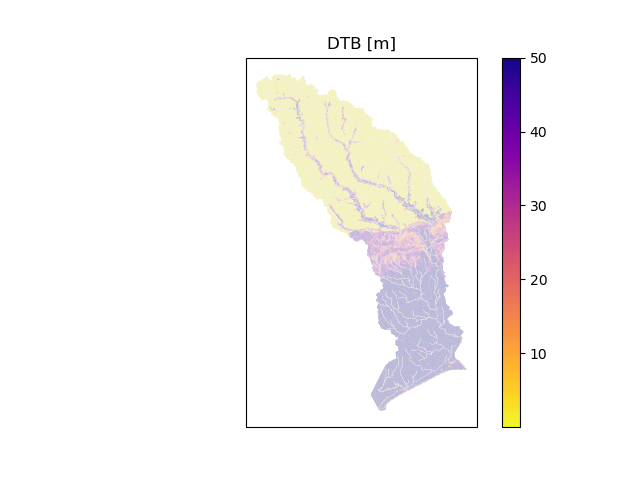

Median depth to bedrock [-] =  27.623733080383193


In [45]:
# plot the resulting surface mesh
fig, ax = watershed_workflow.plot.get_ax(crs)

indices, cmap, norm, ticks, labels = watershed_workflow.colors.generate_indexed_colormap(DTB, cmap='plasma_r')
mp = watershed_workflow.plot.mesh(m2, crs, ax=ax,
                        linewidth=0.1, color=DTB, cmap=cmap, facecolor='color', edgecolor='white')

# mp = watershed_workflow.plot.triangulation(mesh_points3, mesh_tris, crs, ax=ax, 
#                                  color=DTB, cmap='plasma_r', edgecolor='white', linewidth=0.1)
cbar = fig.colorbar(mp)
title = ax.set_title('DTB [m]')
plt.show()
print('Median depth to bedrock [-] = ', np.nanmedian(DTB))
fig.savefig(f'../images/{name}_dtb')

In [72]:
# save data
outputs['DTB'] = f'../../../global_data/meshes/{name}_DTB.pkl'
pickle.dump(DTB, open(outputs['DTB'], 'wb'))

## A combined, complete product?

As a default, we would like a material-driven (e.g. not fields for porosity, perm, etc, but soil classes, each with a common porosity/permeability/vG curve) default that is valid everywhere.  That makes it clear that we must rely on GLHYMPS as the only material-based product that is valid everywhere.  Other products may be layered on top of this, replacing GLHYMPS values, but the underlying layer should be based on GLHYMPS.  To fill in the van Genuchten properties, we relate alpha to permeability and choose a single common n and s_r.


Where available, we then choose to use SSURGO as a layer on top of GLHYMPS.  So start by using all GLHYMPS values, then override ones where SSURGO is valid with those values.  This will be the second model, and has then three layers -- a bedrock layer, a soil layer from 0 to 2m, and a geologic layer, using GLHYMPS values.  SoilGrids depth-to-bedrock will be used to provide the transition between bedrock and (where > 2m) the GLHYMPS "geologic" layer or (where < 2m) the SSURGO "soil" layer.  Where SSURGO has no values, the underlying GLHYMPS values will be used even in the top 2m.

Note, all integer IDs in mesh files must be unique.  This includes Material IDs, side sets, etc.  We create the Material ID map and data frame.  This is used to standardize IDs from multiple data sources.  Traditionally, ATS numbers Material IDs/Side Sets as:

* 0-9 : reserved for boundaries, surface/bottom, etc
* 10-99 : Land Cover side sets, typically NLCD IDs are used
* 100-999 : geologic layer material IDs. 999 is reserved for bedrock.
* 1000-9999 : soil layer material IDs

In [46]:
# map SSURGO mukey to ATS_ID
soil_survey_props_clean['ats_id'] = range(1000, 1000+len(soil_survey_props_clean))
soil_survey_props_clean.set_index('ats_id', inplace=True)

# map GLHYMPS id to ATS_ID
geo_survey_props_clean['ats_id'] = range(100, 100+len(geo_survey_props_clean))
geo_survey_props_clean.set_index('ats_id', inplace=True)

bedrock_props = watershed_workflow.soil_properties.get_bedrock_properties()

# merge the properties databases
subsurface_props = pandas.concat([geo_survey_props_clean,
                                  soil_survey_props_clean,
                                  bedrock_props])

In [47]:
subsurface_props

,native_index,source,permeability [m^2],porosity [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],residual saturation [-],thickness [m]
ats_id,,,,,,,,
100,"(600714, 600725, 600729, 600735, 600766, 60077...",GLHYMPS,1.000000e-13,0.220000,0.000294,2.000000,0.010000,NaN
101,"(596091, 596103, 596127, 596189, 596197, 63062...",GLHYMPS,6.309573e-16,0.190000,0.000025,2.000000,0.010000,NaN
102,"(602066, 1791057)",GLHYMPS,1.000000e-14,0.150000,0.000113,2.000000,0.010000,NaN
103,"(602079, 644147, 644151, 1791058)",GLHYMPS,3.162278e-17,0.120000,0.000007,2.000000,0.010000,NaN
104,"(596176, 596179, 596185, 596190, 596195, 59620...",GLHYMPS,3.162278e-13,0.270000,0.000472,2.000000,0.010000,NaN
...,...,...,...,...,...,...,...,...
2279,3100753,NRCS,3.725695e-13,0.437327,0.000079,1.336146,0.252387,2.03
2280,3220253,NRCS,1.174083e-11,0.420113,0.000357,3.871812,0.133235,2.03
2281,3320966,NRCS,9.100000e-12,0.396749,0.000357,3.719334,0.131273,2.03


2.977771972541987
2.6584471187385796
2.85216408657477
2.851602378995493
3.020944627959687
1.8876576679915855
2.5347480415970596
2.8760035320081303
1.6428263511871617
2.075151130901613
2.660988891246202
1.6785245022565347
1.521912910992094
1.54452073931784
1.521912910992094
3.0726296667990205
2.8098462304300065
2.8098462304300065
1.7479233000339378
1.5549408775930489
1.8244561016114031
1.5117814949671935
1.7451245534230204
1.532617502148807
2.8098462304300074
1.8264573873542023
2.1860576522127744
1.5039489992577337
1.824456101611403
1.6776909146832675
1.824456101611403
2.2567489405649166
3.0967622423187264
3.0683143868359664
1.5501310471442056
1.882959542668305
1.9427537991067103
1.5036123797560088
1.74230051960881
1.50284558749856
1.7103732589532077
1.7064697213421611
1.7064697213421611
1.6800480689190553
1.74230051960881
1.74230051960881
1.74230051960881
1.50284558749856
1.552352787042836
1.7064697213421611
1.50284558749856
1.8453555934894137
3.13918701005775
1.5036123797560088
1.9776

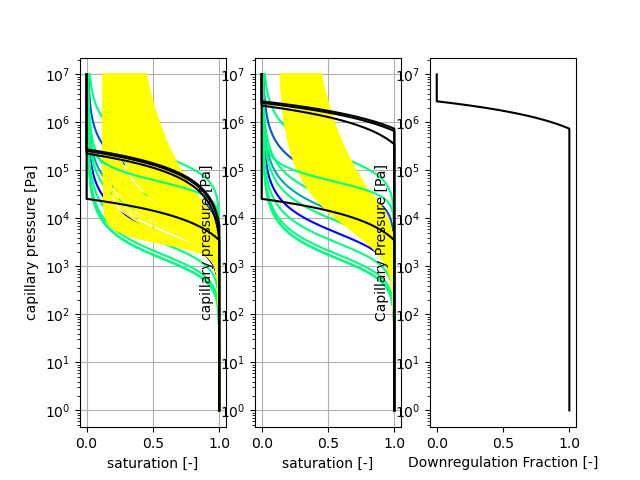

In [48]:
# make a giant plot of all the WRMs (water retention models)

fig = plt.figure()
ax = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

cm_gl = watershed_workflow.colors.cm_mapper(100, 103, 'winter')
cm_ss = watershed_workflow.colors.cm_mapper(1000,1013, 'autumn')

for i in subsurface_props.index:
    if i <= 999:
        cl = cm_gl(i)
    else:
        cl = cm_ss(i)
    alpha = subsurface_props.loc[i]['van Genuchten alpha [Pa^-1]'] # Related to the inverse of air entry suction
    n = subsurface_props.loc[i]['van Genuchten n [-]'] # Related to pore size distribution
    sr = subsurface_props.loc[i]['residual saturation [-]'] # 
    # Transpiration is the only mechanism to dry out the soil after the witting point. If after that point there is not available water, will be "bad flux error" in ATS v1.3
    # This is a temporary fix to avoid that error.
    if n > 1.5 and i > 999:
        print(n)
        vg = plot_wrm.VanGenuchten(alpha, n, sr)
        plot_wrm.plot(vg, ax, cl)
        n = 1.5
        vg = plot_wrm.VanGenuchten(alpha, n, sr)
        plot_wrm.plot(vg, ax2, cl)
    else:
        vg = plot_wrm.VanGenuchten(alpha, n, sr)
        plot_wrm.plot(vg, ax, cl)
        plot_wrm.plot(vg, ax2, cl)
    
    
# include wilting point limiters
wp1 = plot_wrm.WiltingPointLimiter(7400, 275000) # For "Others".    "mafic potential at fully open stomata [Pa]" and "mafic potential at fully closed stomata [Pa]"
wp2 = plot_wrm.WiltingPointLimiter(6600, 255000) # For "Evergreen Forest"
wp3 = plot_wrm.WiltingPointLimiter(3500, 224000) # For "Shrub/Scrub" and "Deciduous Forest"
wp4 = plot_wrm.WiltingPointLimiter(3500,25500) # Use this value to quikcly fix the "bad flux error" in ATS v1.3. Not recommended since it ignores the actual soil properties.
for wp in [wp1, wp2, wp3, wp4]:
    plot_wrm.plot(wp, ax, 'k')

# include wilting point limiters
wp1 = plot_wrm.WiltingPointLimiter(740000, 2750000) # For "Others".    "mafic potential at fully open stomata [Pa]" and "mafic potential at fully closed stomata [Pa]"
wp2 = plot_wrm.WiltingPointLimiter(660000, 2550000) # For "Evergreen Forest"
wp3 = plot_wrm.WiltingPointLimiter(350000, 2240000) # For "Shrub/Scrub" and "Deciduous Forest"
wp4 = plot_wrm.WiltingPointLimiter(3500,25500) # Use this value to quikcly fix the "bad flux error" in ATS v1.3. Not recommended since it ignores the actual soil properties.
for wp in [wp1, wp2, wp3, wp4]:
    plot_wrm.plot(wp, ax2, 'k')

# Plot the regulation function between open and closed stomata (See Sumendra et al. 2023)
# Create a vector of soil water potential values in log scale
f_phi = np.logspace(0, 7, 1000)

# Set step function
f_open = 740000 # "mafic potential at fully open stomata [Pa]"
f_closed = 2750000 # "mafic potential at fully closed stomata [Pa]"
f_phi_step = np.zeros(len(f_phi))
# f_phi_step = (f_phi - f_open) / (f_closed - f_open)
f_phi_step = (f_phi - f_closed) / (f_open - f_closed)
f_phi_step[f_phi < f_open] = 1
f_phi_step[f_phi > f_closed] = 0

ax3.plot(f_phi_step, f_phi, 'k')
ax3.set_yscale('log')
ax3.set_xlabel('Downregulation Fraction [-]')
ax3.set_ylabel('Capillary Pressure [Pa]')


# show grid
ax.grid(True)
ax2.grid(True)
plt.show()

In [49]:
# Change the residual saturation to avoid the "bad flux" error in ATS v1.3
subsurface_props['van Genuchten n [-]'][(subsurface_props['van Genuchten n [-]']>1.5) & (subsurface_props.index>999)] = 1.5

# save the properties to disk for use in generating input file
# outputs['subsurface_properties_filename'] = f'../data-processed/{name}_subsurface_properties.csv'
# subsurface_props.to_csv(outputs['subsurface_properties_filename'])

outputs['subsurface_properties_filename'] = f'../data-processed/{name}_subsurface_properties.pkl'
# Save it as a pickle file
with open(outputs['subsurface_properties_filename'], 'wb') as f:
    pickle.dump(subsurface_props, f)

subsurface_props

/var/folders/2f/3qcvb5n94gjgnh1b6hsrwxy09rfxld/T/ipykernel_29990/1387313252.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subsurface_props['van Genuchten n [-]'][(subsurface_props['van Genuchten n [-]']>1.5) & (subsurface_props.index>999)] = 1.5


,native_index,source,permeability [m^2],porosity [-],van Genuchten alpha [Pa^-1],van Genuchten n [-],residual saturation [-],thickness [m]
ats_id,,,,,,,,
100,"(600714, 600725, 600729, 600735, 600766, 60077...",GLHYMPS,1.000000e-13,0.220000,0.000294,2.000000,0.010000,NaN
101,"(596091, 596103, 596127, 596189, 596197, 63062...",GLHYMPS,6.309573e-16,0.190000,0.000025,2.000000,0.010000,NaN
102,"(602066, 1791057)",GLHYMPS,1.000000e-14,0.150000,0.000113,2.000000,0.010000,NaN
103,"(602079, 644147, 644151, 1791058)",GLHYMPS,3.162278e-17,0.120000,0.000007,2.000000,0.010000,NaN
104,"(596176, 596179, 596185, 596190, 596195, 59620...",GLHYMPS,3.162278e-13,0.270000,0.000472,2.000000,0.010000,NaN
...,...,...,...,...,...,...,...,...
2279,3100753,NRCS,3.725695e-13,0.437327,0.000079,1.336146,0.252387,2.03
2280,3220253,NRCS,1.174083e-11,0.420113,0.000357,1.500000,0.133235,2.03
2281,3320966,NRCS,9.100000e-12,0.396749,0.000357,1.500000,0.131273,2.03


## Mesh extrusion

Given the surface mesh and material IDs on both the surface and subsurface, we can extrude the surface mesh in the vertical to make a 3D mesh.

The most difficult aspect of extrusion is creating meshes that:
1. aren't huge numbers of cells
2. aren't huge cell thicknesses, especially near the surface
3. follow implied interfaces, e.g. bottom of soil and bottom of geologic layer

This is an iterative process that requires some care and some art.

In [50]:
# here we choose the bottom of the domain to be the maximum of the depth to bedrock.  
# This is really up to the user, but we are hard-coding this for this workflow.
#total_thickness = np.ceil(DTB.max())
# total_thickness = np.nanmean(DTB)
total_thickness = np.ceil(np.nanmax(DTB))

if SOILconfig == 1:
    total_thickness = 20 # [m]

if SOILconfig == 2 or SOILconfig == 3:
    total_thickness = 50 # [m]

print(f'total thickness: {total_thickness} m')
# total_thickness = 50 # [m]

total thickness: 50 m


In [51]:
# Generate a dz structure for the top 2m of soil -- it appears from above that the soil thickness is uniformly 2m
#
# here we try for 10 cells, starting at 5cm at the top and going to 50cm at the bottom of the 2m thick soil
dzs, res = watershed_workflow.mesh.optimize_dzs(0.05, 0.5, 2, 10)
print(dzs)

[0.05896722 0.0808916  0.12653611 0.20885521 0.31139112 0.38601833
 0.39951277 0.42782764]


In [52]:
# a 2m soil thickness and a maximum of 50m depth to bedrock suggests a
# geologic layer of 18 - 1m cells
dzs_soil = [0.05, 0.05, 0.05, 0.12, 0.23, 0.5, 0.5, 0.5]
print(sum(dzs_soil))

if SOILconfig == 1:
    dzs_geo = [1.0, 3.0, 4.0,] + 3*[4.0,]
elif SOILconfig == 2 or SOILconfig == 3:
    dzs_geo = [1.0, 3.0, 4.0,] + 3*[4.0,] + 3*[10.0,]

print(dzs_geo)
print(sum(dzs_geo))

2.0
[1.0, 3.0, 4.0, 4.0, 4.0, 4.0, 10.0, 10.0, 10.0]
50.0


In [65]:
print(np.sum(np.isnan(geo_color_new)), np.sum(np.isnan(soil_color_new)), np.sum(np.isnan(DTB)))

0 0 0


In [53]:
# layer extrusion
# -- data structures needed for extrusion
layer_types = []
layer_data = []
layer_ncells = []
layer_mat_ids = []

# -- soil layer --
depth = 0


if SOILconfig == 1 or SOILconfig == 3:
    for dz in dzs_soil:
        depth += 0.5 * dz
        layer_types.append('constant')
        layer_data.append(dz)
        layer_ncells.append(1)
        
        br_or_geo = np.where(depth < DTB, geo_color_new, 999)
        soil_or_br_or_geo = np.where(np.bitwise_and(soil_color_new > 0, depth < soil_thickness),
                                    soil_color_new,
                                    br_or_geo)
        
        layer_mat_ids.append(soil_or_br_or_geo)
        depth += 0.5 * dz
        
    # -- geologic layer --
    for dz in dzs_geo:
        depth += 0.5 * dz
        layer_types.append('constant')
        layer_data.append(dz)
        layer_ncells.append(1)
        layer_mat_ids.append(np.where(depth < DTB, geo_color_new, 999))
        depth += 0.5 * dz

elif SOILconfig == 2:
    for dz in dzs_soil:
        depth += 0.5 * dz
        layer_types.append('constant')
        layer_data.append(dz)
        layer_ncells.append(1)
        
        br_or_geo = np.where(depth < DTB, geo_color_new, 999)
        soil_or_br_or_geo = np.where(np.bitwise_and(soil_color_new > 0, depth < DTB),
                                    soil_color_new,
                                    br_or_geo)
        
        layer_mat_ids.append(soil_or_br_or_geo)
        depth += 0.5 * dz
        
    # -- geologic layer --
    for dz in dzs_geo:
        depth += 0.5 * dz
        layer_types.append('constant')
        layer_data.append(dz)
        layer_ncells.append(1)

        br_or_geo = np.where(depth < DTB, geo_color_new, 999)
        soil_or_br_or_geo = np.where(np.bitwise_and(soil_color_new > 0, depth < DTB),
                                    soil_color_new,
                                    br_or_geo)

        layer_mat_ids.append(soil_or_br_or_geo)
        depth += 0.5 * dz


# print the summary
watershed_workflow.mesh.Mesh3D.summarize_extrusion(layer_types, layer_data, 
                                            layer_ncells, layer_mat_ids)


2024-04-25 14:22:17,638 - root - INFO: Cell summary:
2024-04-25 14:22:17,638 - root - INFO: ------------------------------------------------------------
2024-04-25 14:22:17,638 - root - INFO: l_id	| c_id	|mat_id	| dz		| z_top
2024-04-25 14:22:17,639 - root - INFO: ------------------------------------------------------------
2024-04-25 14:22:17,639 - root - INFO:  00 	| 00 	| 2709 	|   0.050000 	|   0.000000
2024-04-25 14:22:17,639 - root - INFO:  01 	| 01 	| 2709 	|   0.050000 	|   0.050000
2024-04-25 14:22:17,640 - root - INFO:  02 	| 02 	| 2709 	|   0.050000 	|   0.100000
2024-04-25 14:22:17,640 - root - INFO:  03 	| 03 	| 2709 	|   0.120000 	|   0.150000
2024-04-25 14:22:17,640 - root - INFO:  04 	| 04 	| 2709 	|   0.230000 	|   0.270000
2024-04-25 14:22:17,640 - root - INFO:  05 	| 05 	| 2709 	|   0.500000 	|   0.500000
2024-04-25 14:22:17,640 - root - INFO:  06 	| 06 	|  999 	|   0.500000 	|   1.000000
2024-04-25 14:22:17,641 - root - INFO:  07 	| 07 	|  999 	|   0.500000 	|   1.5

In [54]:
# extrude
m3 = watershed_workflow.mesh.Mesh3D.extruded_Mesh2D(m2, layer_types, layer_data, 
                                             layer_ncells, layer_mat_ids)

In [55]:
# add back on land cover side sets ()
surf_ss = m3.side_sets[1]

for index, nlcd_name in zip(nlcd_indices, nlcd_labels):
    where = np.where(lc_channels == index)[0]
    # where = np.where(nlcd_color_new == index)[0]
    print(index, nlcd_name, len(where))
    ss = watershed_workflow.mesh.SideSet(nlcd_name, int(index), 
                            [surf_ss.cell_list[w] for w in where],
                            [surf_ss.side_list[w] for w in where])        
    m3.side_sets.append(ss)

11 Open Water 44483
21 Developed, Open Space 17703
22 Developed, Low Intensity 13924
23 Developed, Medium Intensity 5965
24 Developed, High Intensity 2475
31 Barren Land 892
41 Deciduous Forest 7113
42 Evergreen Forest 138291
43 Mixed Forest 56735
52 Shrub/Scrub 21950
60 Open Channel 1 1461
61 Open Channel 2 5903
62 Open Channel 3 5799
63 Open Channel 4 3158
64 Open Channel 5 3699
65 Open Channel 6 971
71 Grassland/Herbaceous 25614
81 Pasture/Hay 107324
82 Cultivated Crops 6649
90 Woody Wetlands 171799
95 Emergent Herbaceous Wetlands 35433


In [56]:
print('2D labeled sets')
print('---------------')
for ls in m2.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

print('')
print('Extruded 3D labeled sets')
print('------------------------')
for ls in m3.labeled_sets:
    print(f'{ls.setid} : {ls.entity} : {len(ls.ent_ids)} : "{ls.name}"')

print('')
print('Extruded 3D side sets')
print('---------------------')
for ls in m3.side_sets:
    print(f'{ls.setid} : FACE : {len(ls.cell_list)} : "{ls.name}"')

2D labeled sets
---------------
10000 : CELL : 971 : "reaches of StreamOrder 6 in river 0 surface"
10001 : CELL : 2773 : "reaches of StreamOrder 4 in river 0 surface"
10002 : CELL : 5616 : "reaches of StreamOrder 3 in river 0 surface"
10003 : CELL : 4952 : "reaches of StreamOrder 2 in river 0 surface"
10004 : CELL : 823 : "reaches of StreamOrder 1 in river 0 surface"
10005 : CELL : 3354 : "reaches of StreamOrder 5 in river 0 surface"
10006 : CELL : 345 : "reaches of StreamOrder 5 in river 1 surface"
10007 : CELL : 951 : "reaches of StreamOrder 2 in river 1 surface"
10008 : CELL : 638 : "reaches of StreamOrder 1 in river 1 surface"
10009 : CELL : 385 : "reaches of StreamOrder 4 in river 1 surface"
10010 : CELL : 183 : "reaches of StreamOrder 3 in river 1 surface"
10011 : CELL : 12674 : "Neches River"
10012 : CELL : 12674 : "Neches River surface"
10013 : CELL : 66855 : "Neches Rv Saltwater Barrier at Beaumont, TX"
10014 : CELL : 66855 : "Neches Rv Saltwater Barrier at Beaumont, TX surfac

## Save files

In [2]:
# Check if the exodus version is able to pront labeled sets. For that, the below function should exist.
# Write, readme file to fix this problem! 

# If labeled sets are not written in the exodus file, exodus3.py needs to patch using the patch exodus_py.patch. 
# This was done manually because the exodus_py.patch was patching an old exodus version. Just look for the new functions that are added in the exodus_py.patch and put them in exodus3.py

# Path for exodus_py.patch is  ../watershed-workflow/environments/

# Path for exodus3.py ../seacas/build/packages/seacas/scripts/exodus3.py


try:
    import exodus
except Exception:
    try:
        import exodus3 as exodus
    except Exception:
        exodus = None

help(exodus.exodus.num_elem_sets)

Help on function num_elem_sets in module exodus:

num_elem_sets(self)
    get the number of elem sets in the model
    
    >>> num_elem_sets = exo.num_elem_sets()
    
    Returns
    -------
        <int>  num_elem_sets



In [3]:
# name = 'neches'
# outputs = {}

# outputs['m3'] = f'../data-processed/{name}_m3.pkl'
# m3 = pickle.load(open(outputs['m3'], 'rb'))

In [4]:
# save to disk. This takes more than 25 minutes
# Note, is we get the warning "because this exodus installation does not write element sets", we need to patch the exodus3.py file
# To double check that element sets are been written, we can use the python fn "ncdump mesh.exo > nc_dump_mesh.log", and see if in nc_dump_mesh.log, the variables els_status and else_prop1 are populated
outputs['mesh_filename'] = f'../data-processed/{name}.exo'
try:
    os.remove(outputs['mesh_filename'])
except FileNotFoundError:
    pass
m3.write_exodus(outputs['mesh_filename'])


You are using exodus.py v 1.21.2 (seacas-py3), a python wrapper of some of the exodus library.

Copyright (c) 2013-2023 National Technology &
Engineering Solutions of Sandia, LLC (NTESS).  Under the terms of
Contract DE-NA0003525 with NTESS, the U.S. Government retains certain
rights in this software.

Opening exodus file: ../data-processed/neches.exo


2024-04-29 22:31:02,928 - root - INFO: adding side set: 1
2024-04-29 22:31:04,471 - root - INFO: adding side set: 2
2024-04-29 22:31:05,696 - root - INFO: adding side set: 3
2024-04-29 22:31:06,199 - root - INFO: adding side set: 10000
2024-04-29 22:31:06,601 - root - INFO: adding side set: 10001
2024-04-29 22:31:07,032 - root - INFO: adding side set: 10002
2024-04-29 22:31:07,458 - root - INFO: adding side set: 10003
2024-04-29 22:31:07,861 - root - INFO: adding side set: 10004
2024-04-29 22:31:08,259 - root - INFO: adding side set: 10005
2024-04-29 22:31:08,679 - root - INFO: adding side set: 10006
2024-04-29 22:31:09,086 - root - INFO: adding side set: 10007
2024-04-29 22:31:09,490 - root - INFO: adding side set: 10008
2024-04-29 22:31:09,891 - root - INFO: adding side set: 10009
2024-04-29 22:31:10,340 - root - INFO: adding side set: 10010
2024-04-29 22:31:10,750 - root - INFO: adding side set: 10012
2024-04-29 22:31:11,168 - root - INFO: adding side set: 10014
2024-04-29 22:31:11,

Closing exodus file: ../data-processed/neches.exo



Exodus Library Warning/Error: [ex_put_set] in file '../data-processed/neches.exo'
	Bad parameter.


In [59]:
# Save m3, nlcd_indices, nlcd_labels to be used on mesh_xml_Neches.ipynb , these are list objects

outputs['m3'] = f'../data-processed/{name}_m3.pkl'
outputs['nlcd_indices'] =  f'../data-processed/{name}_nlcd_indices.pkl'
outputs['nlcd_labels'] =  f'../data-processed/{name}_nlcd_labels.pkl'

# save data
with open(outputs['nlcd_indices'], 'wb') as f:
    pickle.dump(nlcd_indices, f)
with open(outputs['nlcd_labels'], 'wb') as f:
    pickle.dump(nlcd_labels, f)
with open(outputs['m3'], 'wb') as f:
    pickle.dump(m3, f)